In [1]:
import sys
from pathlib import Path

import polars as pl
import torch
from torchvision.transforms import v2 as transforms

this_path = Path(__file__) if '__file__' in globals() else Path("<undefined>.ipynb").resolve()
work_path = next((p for p in this_path.parents if p.name == "research"), None)
tools_path = work_path / Path("../torch-tools")
sys.path.append(str(tools_path))

ee_tools_path_p = work_path / Path("ee")
sys.path.append(str(ee_tools_path_p))

import utils
import pl_utils
from datasets import fetch_handler
from ee_tools.ee_refiner import EERefiner
from network import Network, Networks
from exp_manager import ExpManager
from torchvision import models
from analyzer import Analyzer


In [2]:
pl_utils.Config()
exp_path = this_path.parent
exp_mgr = ExpManager(exp_path=exp_path)

df = exp_mgr.fetch_results(refresh=False)
df = df.filter(pl.col("epochs") == pl.col("epoch").list.last())

df = df.filter(pl.col("optimizer") == "AdamW")

print(df)

shape: (4, 42)
┌───────────────────────────┬───────────┬────────────────┬──────────────┬─────────────┬───────────────────────────┬───────────────────────────┬─────────────┬───────────┬────────┬────────┬──────┬────────────┬─────────────┬─────────────┬───────┬─────────────────┬─────────────────┬─────┬───────────┬──────────┬────────────┬──────────────────┬───────────┬───────────────────┬───────────┬────────────────┬────────────────┬───────────────────────────┬───────────────────────────┬───────────────────────────┬───────────────────────────┬──────────────────────────┬───────────────────────────┬───────────────────────────┬───────────────────────────┬───────────────────────────┬───────────────────────────┬───────────────────────────┬───────────────────────────┬───────────────────────────┬───────────────────────────┐
│ run_id                    ┆ model_arc ┆ train_dataset  ┆ val_dataset  ┆ num_classes ┆ train_trans               ┆ val_trans                 ┆ train_ndata ┆ val_ndata ┆ epoch

In [3]:
runs_data = df.to_dicts()

ds_root = work_path / "assets/datasets/"
base_train_ds = fetch_handler(ds_root, "cifar100_train")
base_val_ds = fetch_handler(ds_root, "cifar100_val")
# base_val_ds = fetch_handler(ds_root, "cifar100_train")

val_trans = [transforms.ToImage(), transforms.ToDtype(torch.float32, scale=True), base_train_ds.normalizer()]
val_ds = base_val_ds.transform(val_trans)
val_dl = val_ds.loader(batch_size=128)


In [ ]:
# runs_data = runs_data[:1]
for run_data in runs_data:
    run_mgr = exp_mgr.get_run(run_data["run_id"])
    sd = torch.load(run_mgr.fpath("state_dict.pt"))

    net_cls = getattr(models, run_data["model_arc"])
    num_classes = run_data["num_classes"]
    div = run_data["div"]

    network = Network(EERefiner(net_cls(num_classes=num_classes)).cifar_style().multi_narrow(div=div, agg="mean").init_weights().build())
    network.load_state_dict_flexible(sd)

    results = (
        Analyzer(network)
            .calc_fire_rate(key="fire_rate", layer_pattern=r".*relu.*", with_avg=True, with_layer=True, with_counts=True)
            .calc_dead_neurons(key="dead_neurons", layer_pattern=r".*relu.*", with_avg=True, with_layer=True, with_counts=True)
            # .calc_linear_cka(key="linear_cka", layer_pattern=r".*conv.*", channels=16, with_avg=True, with_layer=True, with_group_info=True)
            .calc_linear_cka(key="linear_cka", layer_pattern=r".*conv.*", groups=8, with_avg=True, with_layer=True, with_group_info=True)
            # .calc_linear_cka(key="linear_cka", layer_pattern=r".*conv.*", groups=4*div, with_avg=True, with_layer=True, with_group_info=True)
            .calc_eval(key="eval", with_ens=True, with_path=True, with_oracle=True)
            .flow(val_dl)
    )
    
    
    run_data |= results

    # run_mgr.log_param("fire_rate", avg)
    # run_mgr.sync()
    # torch.save(layer_rates, run_mgr.fpath("layer_rates.pt"))
    # torch.save(layer_neurons, run_mgr.fpath("layer_neurons.pt"))

    # print(avg)
    # print(layer_rates)
    # print(layer_neurons)
# exp_mgr.ref_results()


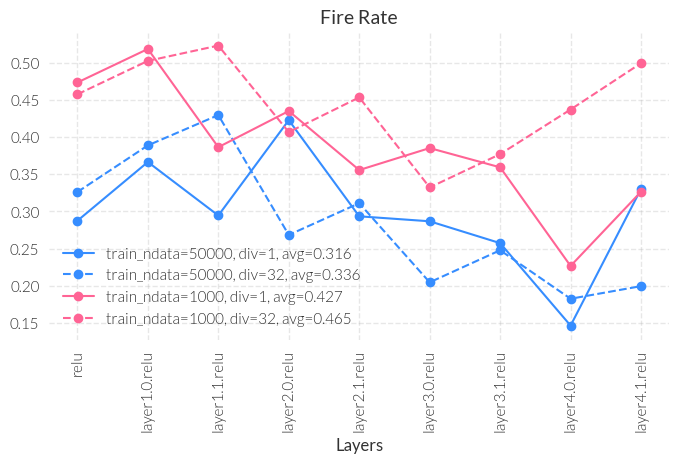

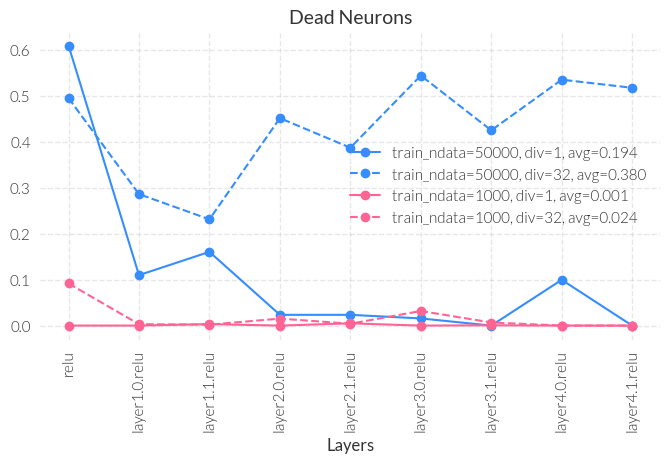

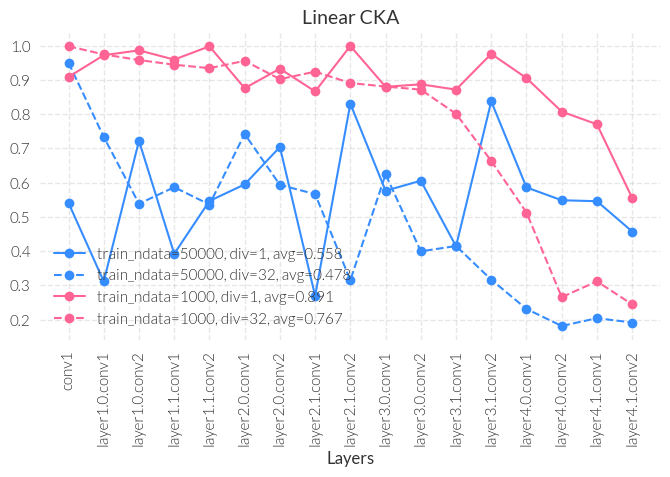

In [5]:
import matplotlib.pyplot as plt
plt.style.use(f'{this_path.parent}/common.mplstyle')
plt.style.use(f'{this_path.parent}/line.mplstyle')

NAME_SLICE = slice(17, None) 

# (キー名, 層別データのインデックス, タイトル)
# 平均値はインデックス0にある前提
metrics_info = [
    ("fire_rate", "layer", "Fire Rate"),
    ("dead_neurons", "layer", "Dead Neurons"),
    ("linear_cka", "layer", "Linear CKA")
]

# 1つ目が色、2つ目が線種に対応します
lines = ["train_ndata", "div"] 

# 利用可能なスタイルと色のリスト
available_linestyles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1)), (0, (1, 1))]
available_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for key, idx, title in metrics_info:
    fig, ax = plt.subplots(figsize=(8, 4))

    # 値とスタイル/色のマッピングを保持する辞書とインデックスを初期化
    linestyle_map = {}
    style_idx = 0
    color_map = {}
    color_idx = 0

    first_data = runs_data[0][key][idx]
    common_layers = list(first_data.keys())
    short_labels = [name[NAME_SLICE] for name in common_layers]
    
    for run_data in runs_data:
        # 平均値(index 0) と 層別データ(index=idx) の取得
        avg_val = run_data[key]["avg"]
        data_dict = run_data[key][idx]
        values = list(data_dict.values())
        
        # ラベル作成: パラメータ情報 + 平均値
        label_parts = [f"{l}={run_data[l]}" for l in lines]
        label_parts.append(f"avg={avg_val:.3f}")
        label_str = ", ".join(label_parts)

        # --- 1つ目の要素で「色（color）」を決定 ---
        color_val_key = lines[0]
        color_val = run_data[color_val_key]

        if color_val not in color_map:
            color_map[color_val] = available_colors[color_idx % len(available_colors)]
            color_idx += 1
        current_color = color_map[color_val]

        # --- 2つ目の要素で「線の形状（linestyle）」を決定 ---
        current_linestyle = '-' 
        if len(lines) > 1:
            style_val_key = lines[1]
            style_val = run_data[style_val_key]

            if style_val not in linestyle_map:
                linestyle_map[style_val] = available_linestyles[style_idx % len(available_linestyles)]
                style_idx += 1
            current_linestyle = linestyle_map[style_val]
        
        # プロット
        ax.plot(range(len(common_layers)), values, marker='o', 
                linestyle=current_linestyle, color=current_color, label=label_str)

    ax.set_xticks(range(len(common_layers)))
    ax.set_xticklabels(short_labels, rotation=90)

    ax.set_title(title)
    ax.set_xlabel("Layers")
    ax.legend()

    plt.show()

In [ ]:
for run_data in runs_data:
    print(run_data["eval"]["path"])

{'acc': 0.7387999892234802, 'loss': 1.5749036073684692}
{'acc': 0.01147802704190326, 'loss': 55.14152111345902}
{'acc': 0.12939999997615814, 'loss': 6.777183532714844}
{'acc': 0.011848046565319237, 'loss': 46.60708148451522}
